# Setup

## Instructions
1. Work on a copy of this notebook: _File_ > _Save a copy in Drive_ (you will need a Google account).
2. (Optional) If you would like to do the deep learning component of this tutorial, turn on the GPU with Edit->Notebook settings->Hardware accelerator->GPU


In [2]:
!pip install -U pysr

Julia and Julia dependencies are installed at first import:

In [3]:
import pysr

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Now, let's import everything else as well as the PySRRegressor:


In [4]:
import sympy
import numpy as np
from matplotlib import pyplot as plt
from pysr import PySRRegressor
from sklearn.model_selection import train_test_split

# Simple PySR example:


First, let's learn a simple function

$$2.5382 \cos(x3) + x0^2 - 2$$

In [22]:
from numpy import sin, cos, exp, log, sqrt
# Dataset

np.random.seed(0)
X = np.random.uniform(-5, 5, size=(200, 6))
# y = 2.5382 * np.cos(X[:, 3]) + X[:, 0] ** 2 - 2
y = 2.2*sin(X[:, 0] + 2*X[:, 1]) - X[:, 5] ** 2 - 3
# Add the y samples with random noise
noise = np.random.normal(loc=0.0, scale=0.5, size=y.shape)
y_noisy = y + noise

By default, we will set up 30 populations of expressions (which evolve independently except for migrations), use 4 threads, and use `"best"` for our model selection strategy:

In [6]:
default_pysr_params = dict(
    populations=30,
    model_selection="best",
)

PySR can run for arbitrarily long, and continue to find more and more accurate expressions. You can set the total number of cycles of evolution with `niterations`, although there are also a [few more ways](https://github.com/MilesCranmer/PySR/pull/134) to stop execution.

**This first execution will take a bit longer to startup, as the library is JIT-compiled. The next execution will be much faster.**

In [7]:
# Learn equations
model = PySRRegressor(
    niterations=30,
    binary_operators=["+", "*"],
    unary_operators=["cos", "exp", "sin"],
    **default_pysr_params,
)

model.fit(X, y)

/usr/local/lib/python3.11/dist-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 5.500e+04
Progress: 295 / 900 total iterations (32.778%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.560e+01  1.594e+01  y = -11.158
3           5.546e+01  1.240e-03  y = x₂ + -11.311
4           5.152e+01  7.370e-02  y = cos(x₅) + -10.987
5           6.759e+00  2.031e+00  y = (x₅ * -1.1931) * x₅
7           2.205e+00  5.600e-01  y = (x₅ * (x₅ * -0.98154)) + -3.1631
9           2.197e+00  1.884e-03  y = (((x₅ * -0.9792) + -0.032535) * x₅) + -3.1778
13          2.092e+00  1.222e-02  y = cos(sin(x₁ + 0.78199)) + (((x₅ * -0.98171) * x₅) + -3....
                                      943)
15          2.021e+00  1.730e-02  y = ((cos(sin(x₁ + 0.78399)) * 2.6415) + ((x₅ * x₅) * -0.9...
                                      82)) + -5.2232
20        

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	    pick      score                                           equation  \
	0          0.000000                                         -11.158129   
	1          0.001240                                    x2 + -11.310948   
	2          0.073704                               cos(x5) + -10.987484   
	3          2.031154                             (x5 * -1.1931329) * x5   
	4          0.560019             (x5 * (x5 * -0.98154354)) + -3.1631415   
	5          0.001884  ((x5 * -0.9791991) * (x5 + 0.03325285)) + -3.1...   
	6          0.012069  ((sin(x0) + (x5 * (x5 + x5))) * -0.4898823) + ...   
	7          0.012668  cos(sin(x1 + 0.7819856)) + (((x5 * -0.98170525...   
	8          1.159914  (((x5 * x5) * -0.9897941) + sin(x0 + (x1 * 2.0...   
	9   >>>>  13.202347  (((x5 * -0.45454526) * x5) + (sin(x0 + (x1 * 1...   
	10         0.046495  ((sin((x0 + (x1 * 2.9430747e-5)) + (x1 * 1.999...   
	11         0.069125  ((sin(x0 + ((x1 * 2.9955272e-5) + (x1 * 1.9999...   
	
	            loss  complexity  
	0   5.559979e+01           1  
	1   5.546202e+01           3  
	2   5.152124e+01           4  
	3   6.758768e+00           5  
	4   2.205166e+00           7  
	5   2.196871e+00           9  
	6   2.118752e+00          12  
	7   2.092081e+00          13  
	8   6.558945e-01          14  
	9   2.235740e-12          16  
	10  1.856311e-12          20  
	11  1.616627e-12          22  
]

  - outputs/20250509_124814_8nG846/hall_of_fame.csv


We can print the model, which will print out all the discovered expressions:

In [8]:
model

PySRRegressor.equations_ = [
	    pick      score                                           equation  \
	0          0.000000                                         -11.158129   
	1          0.001240                                    x2 + -11.310948   
	2          0.073704                               cos(x5) + -10.987484   
	3          2.031154                             (x5 * -1.1931329) * x5   
	4          0.560019             (x5 * (x5 * -0.98154354)) + -3.1631415   
	5          0.001884  ((x5 * -0.9791991) * (x5 + 0.03325285)) + -3.1...   
	6          0.012069  ((sin(x0) + (x5 * (x5 + x5))) * -0.4898823) + ...   
	7          0.012668  cos(sin(x1 + 0.7819856)) + (((x5 * -0.98170525...   
	8          1.159914  (((x5 * x5) * -0.9897941) + sin(x0 + (x1 * 2.0...   
	9   >>>>  13.202347  (((x5 * -0.45454526) * x5) + (sin(x0 + (x1 * 1...   
	10         0.046495  ((sin((x0 + (x1 * 2.9430747e-5)) + (x1 * 1.999...   
	11         0.069125  ((sin(x0 + ((x1 * 2.9955272e-5) + (x1 * 1.9999...   
	
	            loss  complexity  
	0   5.559979e+01           1  
	1   5.546202e+01           3  
	2   5.152124e+01           4  
	3   6.758768e+00           5  
	4   2.205166e+00           7  
	5   2.196871e+00           9  
	6   2.118752e+00          12  
	7   2.092081e+00          13  
	8   6.558945e-01          14  
	9   2.235740e-12          16  
	10  1.856311e-12          20  
	11  1.616627e-12          22  
]

We can also view the SymPy format of the best expression:

In [9]:
model.sympy()

(x5*(-0.45454526)*x5 + sin(x0 + x1*1.9999999) - 1.3636357)*2.200001

We can also view the SymPy of any other expression in the list, using the index of it in `model.equations_`.

In [10]:
model.sympy(2)

cos(x5) - 10.987484

# Experiments 3.0

In [26]:
# Learn equations
model_1 = PySRRegressor(
    niterations=30,
    binary_operators=["+", "*"],
    unary_operators=["cos", "exp", "sin"],
    maxsize=20,
    **default_pysr_params,
)

model_1_noisy = PySRRegressor(
    niterations=30,
    binary_operators=["+", "*"],
    unary_operators=["cos", "exp", "sin"],
    maxsize=20,
    **default_pysr_params,
)

model_1.fit(X, y)

/usr/local/lib/python3.11/dist-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 8.870e+04
Progress: 503 / 900 total iterations (55.889%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.560e+01  1.594e+01  y = -11.159
3           5.546e+01  1.240e-03  y = x₂ + -11.311
4           5.152e+01  7.370e-02  y = cos(x₅) + -10.987
5           6.759e+00  2.031e+00  y = x₅ * (x₅ * -1.1931)
7           2.205e+00  5.600e-01  y = (x₅ * (x₅ * -0.98154)) + -3.1631
9           2.197e+00  1.884e-03  y = (((x₅ + 0.033224) * -0.9792) * x₅) + -3.1777
12          2.175e+00  3.320e-03  y = (exp(x₃ * 0.018186) * -3.1788) + ((x₅ * x₅) * -0.97975...
                                      )
14          2.131e+00  1.015e-02  y = (-3.1787 + ((x₅ * x₅) * -0.9789)) * exp((x₃ * x₀) * 0....
                                      002175)
15          2.120e+00

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                          -11.15821   
	1         0.001240                                    x2 + -11.310965   
	2         0.073704                               cos(x5) + -10.987484   
	3         2.031154                             (x5 * x5) * -1.1931673   
	4   >>>>  0.560019              (x5 * (x5 * -0.9815448)) + -3.1631243   
	5         0.001884  (((x5 + 0.033223763) * -0.97920185) * x5) + -3...   
	6         0.013852  (((x5 * (x5 + x5)) + sin(x0)) * -0.48827732) +...   
	7         0.001364  ((sin(sin(x0)) + (x5 * (x5 + x5))) * -0.488277...   
	8         0.003055  ((sin(x0 * 1.113491) + ((x5 + x5) * x5)) * -0....   
	9         0.007975  (-0.48827732 * (sin(x0 + sin(x3)) + ((x5 + x5)...   
	10        0.000263  (-0.48827732 * (sin(sin(x0 + sin(x3))) + ((x5 ...   
	11        0.013634  (-0.48356646 * (sin(x0 + cos(x1)) + ((x5 * (x5...   
	12        0.036901  ((x5 * ((x5 + x5) * -0.49882573)) + sin((x0 * ...   
	
	         loss  complexity  
	0   55.599790           1  
	1   55.462025           3  
	2   51.521240           4  
	3    6.758767           5  
	4    2.205166           7  
	5    2.196871           9  
	6    2.107448          12  
	7    2.104575          13  
	8    2.098156          14  
	9    2.081489          15  
	10   2.080941          16  
	11   2.052763          17  
	12   1.978394          18  
]

  - outputs/20250509_132200_5msJMk/hall_of_fame.csv


### Model best + top3 według score


In [27]:
best_equation_1 = model_1.sympy()
print("Best by score:", best_equation_1)


top3_1 = model_1.equations_.nlargest(3, "score")

for idx, row in top3_1.iterrows():
    print(f"Index {idx}, score={row.score:.6f}")
    print("Equation:", row.equation)
    print()


Best by score: x5*x5*(-0.9815448) - 3.1631243
Index 3, score=2.031154
Equation: (x5 * x5) * -1.1931673

Index 4, score=0.560019
Equation: (x5 * (x5 * -0.9815448)) + -3.1631243

Index 2, score=0.073704
Equation: cos(x5) + -10.987484



In [28]:
# Learn equations
model_2 = PySRRegressor(
    niterations=30,
    binary_operators=["+", "*", "-", "^"],
    unary_operators=["cos", "exp", "sin", "log"],
    maxsize=30,
    **default_pysr_params,
)

model_2_noisy = PySRRegressor(
    niterations=30,
    binary_operators=["+", "*", "-", "^"],
    unary_operators=["cos", "exp", "sin", "log"],
    maxsize=30,
    **default_pysr_params,
)

model_2.fit(X, y)

/usr/local/lib/python3.11/dist-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pysr/sr.py:89: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 4.550e+04
Progress: 252 / 900 total iterations (28.000%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.560e+01  1.594e+01  y = -11.159
3           5.537e+01  2.051e-03  y = -11.021 - x₅
4           5.152e+01  7.208e-02  y = cos(x₅) + -10.987
5           2.226e+00  3.142e+00  y = -3.0615 - (x₅ * x₅)
7           2.205e+00  4.795e-03  y = (-3.2226 - (x₅ * x₅)) * 0.98155
10          2.169e+00  5.439e-03  y = (0.37044 ^ (cos(x₅ * -0.57509) + -0.86679)) * -4.2389
12          2.144e+00  5.856e-03  y = ((0.43442 ^ (cos(x₅ * -0.53733) + -1.0904)) * -5.5247)...
                                       + 2.4126
───────────────────────────────────────────────────────────────────────────────────────────────────
═══════════════════════════════════════════════

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                         -11.159383   
	1         0.002051                                    -11.020779 - x5   
	2         0.072084                                cos(x5) + -10.98749   
	3         3.142667                             -3.0128696 - (x5 * x5)   
	4         0.004262              (-3.2225523 - (x5 * x5)) * 0.98154867   
	5         0.011886      -3.0156062 + (x5 * ((x4 * 0.033628095) - x5))   
	6         0.001255  (x5 * (((x4 * 0.03362374) + -0.025740316) - x5...   
	7         0.008454  -1.9362824 - ((x5 * x5) + (0.9422905 ^ (sin(x0...   
	8         0.057340  -3.0127952 - ((x5 * x5) + sin(x1 - (sin(x1) * ...   
	9         0.006865  -3.0127952 - ((x5 * x5) + sin(sin(x1 - (x1 * s...   
	10  >>>>  0.372699  -2.8626473 - (sin(x1 - ((-0.23303504 - x0) + s...   
	11        0.002436  (-2.8626473 - (sin(x1 - ((-0.23303504 - x0) + ...   
	
	         loss  complexity  
	0   55.599790           1  
	1   55.372204           3  
	2   51.521240           4  
	3    2.224043           5  
	4    2.205166           7  
	5    2.153365           9  
	6    2.147966          11  
	7    2.129884          12  
	8    2.011192          13  
	9    1.997433          14  
	10   1.375976          15  
	11   1.369289          17  
]

  - outputs/20250509_132208_Lnrckm/hall_of_fame.csv


In [29]:
best_equation_2 = model_2.sympy()
print("Best by score:", best_equation_2)


top3_2 = model_2.equations_.nlargest(3, "score")

for idx, row in top3_2.iterrows():
    print(f"Index {idx}, score={row.score:.6f}")
    print("Equation:", row.equation)
    print()


Best by score: -(x5*x5 + sin(x1 - (-x0 + sin(x1) - 0.23303504))) - 2.8626473
Index 3, score=3.142667
Equation: -3.0128696 - (x5 * x5)

Index 10, score=0.372699
Equation: -2.8626473 - (sin(x1 - ((-0.23303504 - x0) + sin(x1))) + (x5 * x5))

Index 2, score=0.072084
Equation: cos(x5) + -10.98749



In [30]:
# Learn equations
model_3 = PySRRegressor(
    niterations=30,
    binary_operators=["+", "*", "-", "^"],
    unary_operators=["exp", "sin"],
    maxsize=15,
    **default_pysr_params,
)

model_3_noisy = PySRRegressor(
    niterations=30,
    binary_operators=["+", "*", "-", "^"],
    unary_operators=["exp", "sin"],
    maxsize=15,
    **default_pysr_params,
)

model_3.fit(X, y)

/usr/local/lib/python3.11/dist-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pysr/sr.py:89: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.320e+05
Progress: 772 / 900 total iterations (85.778%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.560e+01  1.594e+01  y = -11.158
3           5.537e+01  2.051e-03  y = -11.021 - x₅
4           5.462e+01  1.364e-02  y = -11.157 - sin(x₀)
5           2.224e+00  3.201e+00  y = -3.0128 - (x₅ * x₅)
7           2.205e+00  4.262e-03  y = ((x₅ * x₅) * -0.98155) - 3.1631
9           2.153e+00  1.189e-02  y = (x₅ * ((x₄ * 0.03329) - x₅)) + -3.0191
10          2.134e+00  9.020e-03  y = (-3.0123 - (x₅ * x₅)) - (sin(x₀) * 0.41066)
11          2.134e+00  5.740e-05  y = (-3.0123 - (x₅ * x₅)) - sin(sin(x₀) * 0.41066)
12          2.106e+00  1.323e-02  y = (((x₅ * x₅) * -0.97735) + (sin(x₀) * -0.43333)) - 3.19...
                                      68
13

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                         -11.158129   
	1         0.002051                                    -11.020784 - x5   
	2         0.013642                               -11.157398 - sin(x0)   
	3   >>>>  3.201109                             -3.0127757 - (x5 * x5)   
	4         0.004262               ((x5 * x5) * -0.9815461) - 3.1631017   
	5         0.011890       (x5 * ((x4 * 0.033289626) - x5)) + -3.019098   
	6         0.009021  (-3.0123432 - (x5 * x5)) - (sin(x0) * 0.41065782)   
	7         0.000058  (-3.0123432 - (x5 * x5)) - sin(sin(x0) * 0.410...   
	8         0.013226  (((x5 * x5) * -0.97734785) + (sin(x0) * -0.433...   
	9         0.000633  (x5 * (x5 * -0.9771891)) + ((sin(sin(x0)) * -0...   
	10        0.019401  (-1.97442 - (1.4982696 ^ sin(x0))) + (((x4 * 0...   
	11        0.006736  (-3.0123432 - (x5 * x5)) - (sin(x0 - sin(x5 * ...   
	
	         loss  complexity  
	0   55.599790           1  
	1   55.372204           3  
	2   54.621950           4  
	3    2.224043           5  
	4    2.205166           7  
	5    2.153344           9  
	6    2.134007          10  
	7    2.133884          11  
	8    2.105847          12  
	9    2.104514          13  
	10   2.064077          14  
	11   2.050221          15  
]

  - outputs/20250509_132222_fG9qHE/hall_of_fame.csv


In [31]:
best_equation_3 = model_3.sympy()
print("Best by score:", best_equation_3)


top3_3 = model_3.equations_.nlargest(3, "score")

for idx, row in top3_3.iterrows():
    print(f"Index {idx}, score={row.score:.6f}")
    print("Equation:", row.equation)
    print()


Best by score: -x5*x5 - 3.0127757
Index 3, score=3.201109
Equation: -3.0127757 - (x5 * x5)

Index 10, score=0.019401
Equation: (-1.97442 - (1.4982696 ^ sin(x0))) + (((x4 * 0.031968687) - x5) * x5)

Index 2, score=0.013642
Equation: -11.157398 - sin(x0)



# Same experiments with noise


In [32]:
model_1_noisy.fit(X, y_noisy)
best_equation_1_noisy = model_1_noisy.sympy()
print("Best by score:", best_equation_1_noisy)


top3_1_noisy = model_1_noisy.equations_.nlargest(3, "score")

for idx, row in top3_1_noisy.iterrows():
    print(f"Index {idx}, score={row.score:.6f}")
    print("Equation:", row.equation)
    print()



/usr/local/lib/python3.11/dist-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 9.420e+04
Progress: 554 / 900 total iterations (61.556%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.566e+01  1.594e+01  y = -11.093
3           5.560e+01  5.027e-04  y = x₂ + -11.246
4           5.159e+01  7.493e-02  y = cos(x₅) + -10.922
5           6.855e+00  2.018e+00  y = (x₅ * x₅) * -1.188
7           2.449e+00  5.148e-01  y = (x₅ * (x₅ * -0.97982)) + -3.1117
9           2.434e+00  2.937e-03  y = ((x₅ + 0.043788) * (x₅ * -0.97674)) + -3.1309
11          2.434e+00  -0.000e+00  y = ((((x₅ + 0.087619) + x₅) * x₅) + 6.4109) * -0.48837
12          2.347e+00  3.654e-02  y = ((sin(x₀) + 6.4652) + ((x₅ + x₅) * x₅)) * -0.48744
13          2.345e+00  6.665e-04  y = ((sin(sin(x₀)) + ((x₅ + x₅) * x₅)) * -0.4878) + -3.144...
                       

[ Info: Final population:
[ Info: Results saved to:


Best by score: x5*x5*(-0.9883664) + sin(x0 + x1 + x1) - 3.037272
Index 3, score=2.018258
Equation: (x5 * x5) * -1.1879803

Index 9, score=0.974183
Equation: ((x5 * (x5 * -0.9883664)) + -3.037272) + sin(x1 + (x0 + x1))

Index 4, score=0.514755
Equation: (x5 * (x5 * -0.9798245)) + -3.1116529

  - outputs/20250509_132228_ICirgS/hall_of_fame.csv


In [33]:
model_2_noisy.fit(X, y_noisy)
best_equation_2_noisy = model_2_noisy.sympy()
print("Best by score:", best_equation_2_noisy)


top3_2_noisy = model_2_noisy.equations_.nlargest(3, "score")

for idx, row in top3_2_noisy.iterrows():
    print(f"Index {idx}, score={row.score:.6f}")
    print("Equation:", row.equation)
    print()


/usr/local/lib/python3.11/dist-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pysr/sr.py:89: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 5.620e+04
Progress: 297 / 900 total iterations (33.000%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.566e+01  1.594e+01  y = -11.093
3           5.528e+01  3.374e-03  y = -10.955 - x₅
4           5.159e+01  6.919e-02  y = cos(x₅) + -10.922
5           2.471e+00  3.039e+00  y = -2.9473 - (x₅ * x₅)
7           2.463e+00  1.617e-03  y = ((-0.031331 - x₅) * x₅) + -2.943
9           2.449e+00  2.854e-03  y = (-2.4166 - (x₅ * (0.97674 * x₅))) + -0.7143
11          2.434e+00  3.052e-03  y = (-2.4166 - (((x₅ + 0.043791) * 0.97674) * x₅)) + -0.71...
                                      43
17          2.432e+00  1.649e-04  y = ((-3.0608 - (x₀ * -0.01016)) * ((-0.50552 - ((x₅ * x₅)...
                                       * 0.21578)) * -1.4808)) - 0.

In [34]:
model_3_noisy.fit(X, y_noisy)
best_equation_3_noisy = model_3_noisy.sympy()
print("Best by score:", best_equation_3_noisy)


top3_3_noisy = model_3_noisy.equations_.nlargest(3, "score")

for idx, row in top3_3_noisy.iterrows():
    print(f"Index {idx}, score={row.score:.6f}")
    print("Equation:", row.equation)
    print()


/usr/local/lib/python3.11/dist-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pysr/sr.py:89: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 1.450e+05
Progress: 828 / 900 total iterations (92.000%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.566e+01  1.594e+01  y = -11.092
3           5.528e+01  3.374e-03  y = -10.955 - x₅
4           5.467e+01  1.108e-02  y = -11.108 - sin(x₀)
5           2.471e+00  3.097e+00  y = -2.9474 - (x₅ * x₅)
7           2.449e+00  4.585e-03  y = ((x₅ * x₅) * -0.97983) + -3.1116
9           2.434e+00  2.937e-03  y = (x₅ * ((x₅ * -0.97674) + -0.042768)) + -3.1309
11          2.363e+00  1.485e-02  y = (x₅ * ((x₅ * -0.97839) + (x₄ * 0.036651))) - 3.1303
12          2.346e+00  7.329e-03  y = (sin(x₀) * -0.44096) + (((x₅ * x₅) * -0.97556) - 3.145...
                                      9)
13          2.306e+00  1.716e-02  y = (x₅ * (x₅ * -0.97218)) + (((0.25

# Output into a DF

In [35]:
import pandas as pd

data = []

for model_name in ['model_1', 'model_2', 'model_3','model_1_noisy', 'model_2_noisy', 'model_3_noisy']:
    model = globals()[model_name]  # Get the model object from the global namespace

    best_equation = model.sympy()
    top3 = model.equations_.nlargest(3, "score")

    # Add data for the best equation
    data.append([model_name, 'best', best_equation, top3.iloc[0]['score']])  # Changed to iloc to access row

    # Add data for the top 3 equations
    for idx, row in top3.iterrows():
        data.append([model_name, idx, row['equation'], row['score']])

df = pd.DataFrame(data, columns=['Model', 'Equation_Type', 'Equation', 'Score'])

display(df)

,Model,Equation_Type,Equation,Score
0,model_1,best,x5*x5*(-0.9815448) - 3.1631243,2.031154
1,model_1,3,(x5 * x5) * -1.1931673,2.031154
2,model_1,4,(x5 * (x5 * -0.9815448)) + -3.1631243,0.560019
3,model_1,2,cos(x5) + -10.987484,0.073704
4,model_2,best,-(x5*x5 + sin(x1 - (-x0 + sin(x1) - 0.23303504...,3.142667
5,model_2,3,-3.0128696 - (x5 * x5),3.142667
6,model_2,10,-2.8626473 - (sin(x1 - ((-0.23303504 - x0) + s...,0.372699
7,model_2,2,cos(x5) + -10.98749,0.072084
8,model_3,best,-x5*x5 - 3.0127757,3.201109
9,model_3,3,-3.0127757 - (x5 * x5),3.201109


In [36]:
df.to_csv('results.csv')

## Output

`model.equations_` is a Pandas DataFrame. We can export the results in various ways:

In [11]:
model.latex()

'\\left(\\left(x_{5} x_{5} + \\cos{\\left(x_{0} + \\cos{\\left(x_{1} \\left(-2.10\\right) \\right)} 1.84 \\right)}\\right) \\left(-2.67\\right) - 8.42\\right) 0.370'

These is also `model.sympy(), model.jax(), model.pytorch()`. All of these can take an index as input, to get the result for an arbitrary equation in the list.

We can also use `model.predict` for arbitrary equations, with the default equation being the one chosen by `model_selection`:

In [12]:
ypredict = model.predict(X)
ypredict_simpler = model.predict(X, 2)

print("Default selection MSE:", np.power(ypredict - y, 2).mean())
print("Manual selection MSE for index 2:", np.power(ypredict_simpler - y, 2).mean())

Default selection MSE: 1.3783822391115002
Manual selection MSE for index 2: 51.52125101162798


# Custom operators

A full list of operators is given here: https://astroautomata.com/PySR/operators,
but we can also use any binary or unary operator in `julia`, or define our own as arbitrary functions.

Say that we want a command to do quartic powers:

$$ y = x_0^4 - 2 $$

In [13]:
y = X[:, 0] ** 4 - 2

We can do this by passing a string in Julia syntax.

We also define the operator in sympy, with `extra_sympy_mappings`, to enable its use in `predict`, and other export functions.

In [14]:
model = PySRRegressor(
    niterations=5,
    populations=40,
    binary_operators=["+", "*"],
    unary_operators=["cos", "exp", "sin", "quart(x) = x^4"],
    extra_sympy_mappings={"quart": lambda x: x**4},
)
model.fit(X, y)

/usr/local/lib/python3.11/dist-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.088e+04  1.594e+01  y = 142.68
2           4.000e+00  8.951e+00  y = quart(x₀)
4           7.796e-10  7.970e+00  y = quart(x₀) + -2
12          7.667e-10  2.087e-03  y = (quart(x₀) + (((x₅ + -0.42029) * -1.2234e-06) + -0.004...
                                      4137)) + -1.9956
13          7.619e-10  6.249e-03  y = ((((-0.99259 + x₅) * -1.2234e-06) + sin(-0.0044137)) +...
                                       quart(x₀)) + -1.9956
14          7.422e-10  2.631e-02  y = (quart(x₀) + ((((x₅ + x₄) + 2.0024) * -7.7767e-07) + -...
                                      0.0044117)) + -1.9956
16          7.347e-10  5.071e-03  y = (quart(x₀) + ((-1.2234e-06 * (x₅ + (-0.66479 + sin(x₁)...
                                      ))) + sin(-0.0044137))) + -1.9956
21          7.285e-10  1.685e-03  y = (quart(x₀) + ((((sin(x₀ * quart(quart(x₅ *

[ Info: Results saved to:


PySRRegressor.equations_ = [
	   pick      score                                           equation  \
	0         0.000000                                           142.6826   
	1         8.951517                                          quart(x0)   
	2  >>>>  11.179253                             quart(x0) + -2.0000014   
	3         0.002087  (quart(x0) + (((x5 + -0.42029023) * -1.2233743...   
	4         0.006250  ((((-0.99259084 + x5) * -1.2233743e-6) + sin(-...   
	5         0.026309  (quart(x0) + ((((x5 + x4) + 2.002354) * -7.776...   
	6         0.005071  (quart(x0) + ((-1.2233743e-6 * (x5 + (-0.66478...   
	7         0.001685  (quart(x0) + ((((sin(x0 * quart(quart(x5 * -0....   
	8         0.005794  (sin(((x5 + (sin(x0 * quart(quart(x5 * -0.5264...   
	9         0.001972  (((((x5 + -0.9230697) + sin(sin(((x4 * quart(q...   
	
	           loss  complexity  
	0  3.087834e+04           1  
	1  3.999994e+00           2  
	2  7.796215e-10           4  
	3  7.667155e-10          12  
	4  7.619387e-10          13  
	5  7.421545e-10          14  
	6  7.346649e-10          16  
	7  7.285004e-10          21  
	8  7.242920e-10          22  
	9  7.214407e-10          24  
]

  - outputs/20250509_123124_VWjtU0/hall_of_fame.csv


In [15]:
model.sympy()

x0**4 - 2.0000014

Since `quart` is arguably more complex than the other operators, you can also give it a different complexity, using, e.g., `complexity_of_operators={"quart": 2}` to give it a complexity of 2 (instead of the default 2). You can also define custom complexities for variables and constants (`complexity_of_variables` and `complexity_of_constants`, respectively - both take a single number).


One can also add a binary operator, with, e.g., `"myoperator(x, y) = x^2 * y"`. All Julia operators that work on scalar 32-bit floating point values are available.

Make sure that any operator you add is valid over the real line. So, e.g., you will need to define `"mysqrt(x) = sqrt(abs(x))"` to enable it for negative numbers,
or, simply have it return a very large number for bad inputs (to prevent negative input in a soft way):
`"mysqrt(x::T) where {T} = (x >= 0) ? x : T(-1e9)"` (Julia syntax for a template function of input type `T`), which will make `mysqrt(x)` return -10^9 for negative x–hurting the loss of the equation.

## Scoring

Using `model_selection="best"`selects the equation with the max score and prints it. But in practice it is best to look through all the equations manually, select an equation above some MSE threshold, and then use the score to select among that loss threshold.

Here, "score" is defined by:
$$ \text{score} = - \log(\text{loss}_i/\text{loss}_{i-1})/
(\text{complexity}_i - \text{complexity}_{i-1})$$

This scoring is motivated by the common strategy of looking for drops in the loss-complexity curve.

From Schmidt & Lipson (2009) -

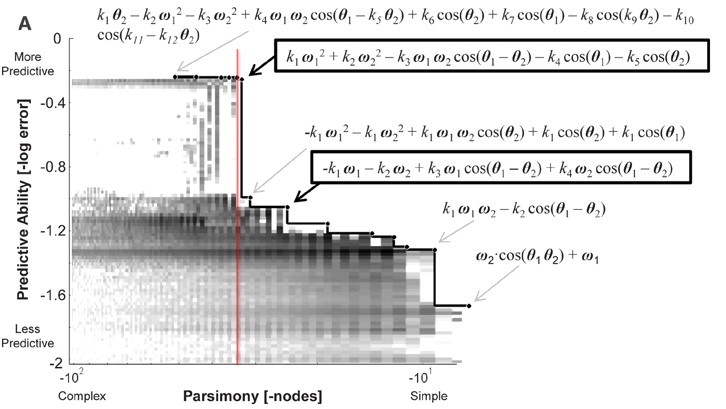

# Noise example

Here is an example with noise. Known Gaussian noise with $\sigma$ between 0.1 and 5.0. We record samples of $y$:

$$ \sigma \sim U(0.1, 5.0) $$
$$ \epsilon \sim \mathcal{N}(0, \sigma^2)$$
$$ y = 5\;\cos(3.5 x_0) - 1.3 + \epsilon.$$
We have 5 features, say. The weights change the loss function to be:
$$MSE = \sum [(y - f(x))^2*w],$$

so in this example, we can set:
$$w = 1/\sigma^2.$$

In [16]:
np.random.seed(0)
N = 3000
upper_sigma = 5
X = 2 * np.random.rand(N, 5)
sigma = np.random.rand(N) * (5 - 0.1) + 0.1
eps = sigma * np.random.randn(N)
y = 5 * np.cos(3.5 * X[:, 0]) - 1.3 + eps

Let's look at this dataset:

Text(0, 0.5, '$y$')

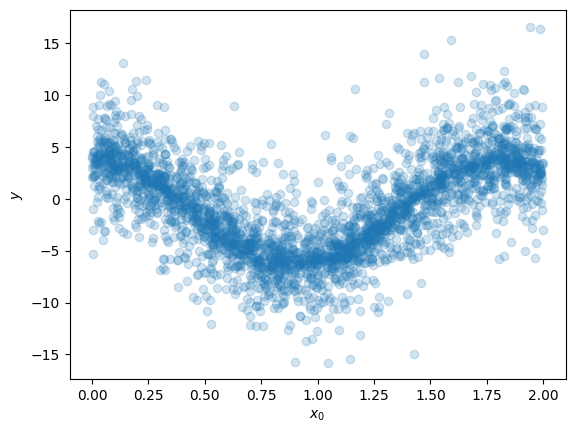

In [17]:
plt.scatter(X[:, 0], y, alpha=0.2)
plt.xlabel("$x_0$")
plt.ylabel("$y$")

Define some weights to use:

In [18]:
weights = 1 / sigma**2

In [19]:
weights[:5]

array([0.25199296, 0.0775419 , 0.11515701, 0.1781281 , 0.0448131 ])

Let's run PySR again:

In [20]:
model = PySRRegressor(
    elementwise_loss="myloss(x, y, w) = w * abs(x - y)",  # Custom loss function with weights.
    niterations=20,
    populations=20,  # Use more populations
    binary_operators=["+", "*"],
    unary_operators=["cos"],
)
model.fit(X, y, weights=weights)

/usr/local/lib/python3.11/dist-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 3.900e+03
Progress: 18 / 400 total iterations (4.500%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.471e+00  1.594e+01  y = -2.5588
2           3.400e+00  2.077e-02  y = cos(x₃)
3           3.194e+00  6.247e-02  y = x₀ + -2.5626
4           3.021e+00  5.556e-02  y = cos(x₀) * -1.9254
6           1.781e+00  2.643e-01  y = (x₀ * cos(x₀)) * -8.3797
13          1.552e+00  1.961e-02  y = ((((x₀ + (x₀ + 5.7684)) * x₀) + -17.341) * x₀) + 5.194...
                                      1
14          1.210e+00  2.487e-01  y = (x₀ + (x₀ + x₀)) * ((-1.4272 * cos(x₀ * x₀)) + -0.7131...
                                      1)
16          4.417e-01  5.041e-01  y = (((cos(x₀ * 3.6313) + 0.60817) + ((x₀ + -2.0494) * x₀)...
                                   

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	   pick     score                                     equation      loss  \
	0        0.000000                                   -1.1848849  3.304065   
	1        0.018599                              x0 + -2.0875044  3.183419   
	2        0.148812                         cos(x0 * -3.3336654)  2.743251   
	3        0.461794               cos(x0 * 3.291488) * 4.9963384  1.089323   
	4  >>>>  0.624239  (cos(x0 * 3.495823) * 5.02808) + -1.2880013  0.312572   
	
	   complexity  
	0           1  
	1           3  
	2           4  
	3           6  
	4           8  
]

  - outputs/20250509_123214_Xgk8AT/hall_of_fame.csv


Let's see if we get similar results to the true equation

In [21]:
model

PySRRegressor.equations_ = [
	   pick     score                                     equation      loss  \
	0        0.000000                                   -1.1848849  3.304065   
	1        0.018599                              x0 + -2.0875044  3.183419   
	2        0.148812                         cos(x0 * -3.3336654)  2.743251   
	3        0.461794               cos(x0 * 3.291488) * 4.9963384  1.089323   
	4  >>>>  0.624239  (cos(x0 * 3.495823) * 5.02808) + -1.2880013  0.312572   
	
	   complexity  
	0           1  
	1           3  
	2           4  
	3           6  
	4           8  
]

We can also filter all equations up to 2x the most accurate equation, then select the best score from that list:

In [22]:
best_idx = model.equations_.query(
    f"loss < {2 * model.equations_.loss.min()}"
).score.idxmax()
model.sympy(best_idx)

cos(x0*3.495823)*5.02808 - 1.2880013

We can also use `denoise=True`, which will run the input through a Gaussian process to denoise the dataset, before fitting on it.

Let's look at the fit:

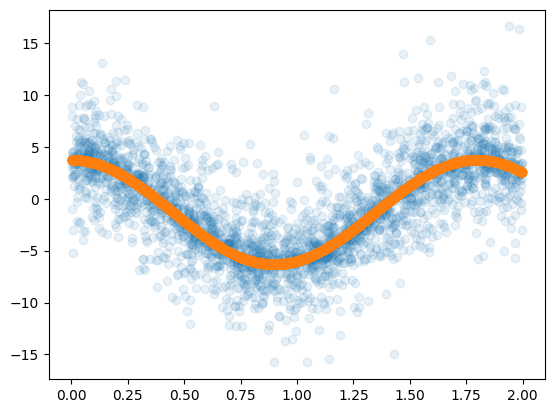

In [23]:
plt.scatter(X[:, 0], y, alpha=0.1)
y_prediction = model.predict(X, index=best_idx)
plt.scatter(X[:, 0], y_prediction)

# Multiple outputs

For multiple outputs, multiple equations are returned:

In [24]:
X = 2 * np.random.randn(100, 5)
y = 1 / X[:, [0, 1, 2]]

In [25]:
model = PySRRegressor(
    binary_operators=["+", "*"],
    unary_operators=["inv(x) = 1/x"],
    extra_sympy_mappings={"inv": lambda x: 1 / x},
)
model.fit(X, y)

/usr/local/lib/python3.11/dist-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 8.670e+04
Progress: 506 / 9300 total iterations (5.441%)
════════════════════════════════════════════════════════════════════════════════════════════════════
Best equations for output 1
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.969e+01  1.594e+01  y₀ = -1.3214
2           3.991e-14  1.594e+01  y₀ = inv(x₀)
6           3.991e-14  5.560e-05  y₀ = inv(x₀) + (x₂ * 5.334e-09)
7           3.300e-14  1.901e-01  y₀ = inv(x₄ * (x₀ * inv(x₄)))
11          2.536e-14  6.582e-02  y₀ = ((inv(x₀) * -0.22485) + (inv(x₀) * -0.49289)) * -1.3...
                                       933
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Best equations for output 2
─────────────────────────────────────────────

[ Info: Final populations:
[ Info: Output 1:
[ Info: Output 2:
[ Info: Output 3:
[ Info: Results saved to:


PySRRegressor.equations_ = [
[
	   pick      score                                           equation  \
	0         0.000000                                         -1.3214486   
	1        34.757929                                            inv(x0)   
	2         0.000056                       inv(x0) + (x2 * 5.333959e-9)   
	3         0.240090                inv((inv(x1) * 1.9436801e-10) + x0)   
	4         0.184806      (inv(x0) * 0.8128569) + (0.1871431 * inv(x0))   
	5         0.082676  inv((((-2.6487193 + inv(x3)) * (inv(x3) + inv(...   
	6         0.044696  inv(((inv(x3 * x3) + inv((-1.067869 * x1) * x4...   
	7  >>>>   0.424456  inv(x0 + (((inv(x3) * (inv(x3) + -2.6487193)) ...   
	8         0.004559  inv((((inv(x3) * ((x1 * (inv((x1 * x0) + -0.77...   
	
	           loss  complexity  
	0  4.969471e+01           1  
	1  3.991474e-14           2  
	2  3.990586e-14           6  
	3  3.138822e-14           7  
	4  2.168932e-14           9  
	5  1.320721e-14          15  
	6  1.262990e-14          16  
	7  3.534950e-15          19  
	8  3.392841e-15          28  
], [
	    pick      score                                           equation  \
	0          0.000000                                                 x2   
	1         33.233427                                            inv(x1)   
	2          0.000002                     inv(x1) + (x2 * -5.7857563e-9)   
	3          5.158055                inv(x1) + (inv(x1) * -4.0104567e-8)   
	4          0.284352           inv(x1) + (inv(x1 * x1) * 2.2310753e-10)   
	5          0.001757  inv(x1) + ((inv(x1) * -0.1859119) * ((x0 * -2....   
	6          0.071873  ((inv(x1 * x1) + (inv(x2) * x1)) * 2.8244437e-...   
	7          0.001898  inv(x1) + ((inv((-1.1886772 + x1) * x2) + inv(...   
	8   >>>>   0.136135  inv(x1) + ((inv(((x1 + x1) + 0.3629151) * x1) ...   
	9          0.004179  ((inv(x1 * x1) + inv((x2 * ((x2 + -0.6725123) ...   
	10         0.035384  (((inv(x1 * x1) + (inv(x2) * x1)) + inv(((x1 +...   
	11         0.004688  inv(x1) + (((x1 * inv(x2)) + (inv(x1 * x1) + i...   
	12         0.000157  (((inv((x2 * (x2 + (x2 + -0.6725123))) + -2.19...   
	
	            loss  complexity  
	0   6.332148e+02           1  
	1   2.335916e-12           2  
	2   2.335898e-12           6  
	3   1.343814e-14           7  
	4   7.609469e-15           9  
	5   7.556178e-15          13  
	6   7.032153e-15          14  
	7   7.005507e-15          16  
	8   5.335732e-15          18  
	9   5.291323e-15          20  
	10  4.758416e-15          23  
	11  4.714007e-15          25  
	12  4.711786e-15          28  
], [
	   pick      score                                           equation  \
	0         0.000000                                          13.140349   
	1        32.484459                                            inv(x2)   
	2         4.998341                              inv(x2 + 6.12978e-11)   
	3  >>>>   0.067987      inv(x2 + ((x0 * (x0 * -1.2245074e-10)) * x0))   
	4         0.006397  inv(x2 + (((inv(x0 + -2.6898115) + x0) * x0) *...   
	5         0.025650  inv((((x0 * (inv((x0 + (x3 * 1.5989599)) + x3)...   
	6         0.007336  inv((((x0 * (x0 + inv(x1 + -0.6677658))) + inv...   
	
	           loss  complexity  
	0  1.910123e+04           1  
	1  1.490184e-10           2  
	2  6.787903e-15           4  
	3  4.514167e-15          10  
	4  4.372058e-15          15  
	5  3.945733e-15          19  
	6  3.803624e-15          24  
]]

  - outputs/20250509_123259_3XbnpJ/hall_of_fame_output3.csv


In [26]:
model

PySRRegressor.equations_ = [
[
	   pick      score                                           equation  \
	0         0.000000                                         -1.3214486   
	1        34.757929                                            inv(x0)   
	2         0.000056                       inv(x0) + (x2 * 5.333959e-9)   
	3         0.240090                inv((inv(x1) * 1.9436801e-10) + x0)   
	4         0.184806      (inv(x0) * 0.8128569) + (0.1871431 * inv(x0))   
	5         0.082676  inv((((-2.6487193 + inv(x3)) * (inv(x3) + inv(...   
	6         0.044696  inv(((inv(x3 * x3) + inv((-1.067869 * x1) * x4...   
	7  >>>>   0.424456  inv(x0 + (((inv(x3) * (inv(x3) + -2.6487193)) ...   
	8         0.004559  inv((((inv(x3) * ((x1 * (inv((x1 * x0) + -0.77...   
	
	           loss  complexity  
	0  4.969471e+01           1  
	1  3.991474e-14           2  
	2  3.990586e-14           6  
	3  3.138822e-14           7  
	4  2.168932e-14           9  
	5  1.320721e-14          15  
	6  1.262990e-14          16  
	7  3.534950e-15          19  
	8  3.392841e-15          28  
], [
	    pick      score                                           equation  \
	0          0.000000                                                 x2   
	1         33.233427                                            inv(x1)   
	2          0.000002                     inv(x1) + (x2 * -5.7857563e-9)   
	3          5.158055                inv(x1) + (inv(x1) * -4.0104567e-8)   
	4          0.284352           inv(x1) + (inv(x1 * x1) * 2.2310753e-10)   
	5          0.001757  inv(x1) + ((inv(x1) * -0.1859119) * ((x0 * -2....   
	6          0.071873  ((inv(x1 * x1) + (inv(x2) * x1)) * 2.8244437e-...   
	7          0.001898  inv(x1) + ((inv((-1.1886772 + x1) * x2) + inv(...   
	8   >>>>   0.136135  inv(x1) + ((inv(((x1 + x1) + 0.3629151) * x1) ...   
	9          0.004179  ((inv(x1 * x1) + inv((x2 * ((x2 + -0.6725123) ...   
	10         0.035384  (((inv(x1 * x1) + (inv(x2) * x1)) + inv(((x1 +...   
	11         0.004688  inv(x1) + (((x1 * inv(x2)) + (inv(x1 * x1) + i...   
	12         0.000157  (((inv((x2 * (x2 + (x2 + -0.6725123))) + -2.19...   
	
	            loss  complexity  
	0   6.332148e+02           1  
	1   2.335916e-12           2  
	2   2.335898e-12           6  
	3   1.343814e-14           7  
	4   7.609469e-15           9  
	5   7.556178e-15          13  
	6   7.032153e-15          14  
	7   7.005507e-15          16  
	8   5.335732e-15          18  
	9   5.291323e-15          20  
	10  4.758416e-15          23  
	11  4.714007e-15          25  
	12  4.711786e-15          28  
], [
	   pick      score                                           equation  \
	0         0.000000                                          13.140349   
	1        32.484459                                            inv(x2)   
	2         4.998341                              inv(x2 + 6.12978e-11)   
	3  >>>>   0.067987      inv(x2 + ((x0 * (x0 * -1.2245074e-10)) * x0))   
	4         0.006397  inv(x2 + (((inv(x0 + -2.6898115) + x0) * x0) *...   
	5         0.025650  inv((((x0 * (inv((x0 + (x3 * 1.5989599)) + x3)...   
	6         0.007336  inv((((x0 * (x0 + inv(x1 + -0.6677658))) + inv...   
	
	           loss  complexity  
	0  1.910123e+04           1  
	1  1.490184e-10           2  
	2  6.787903e-15           4  
	3  4.514167e-15          10  
	4  4.372058e-15          15  
	5  3.945733e-15          19  
	6  3.803624e-15          24  
]]

# Julia packages and types

PySR uses [SymbolicRegression.jl](https://github.com/MilesCranmer/SymbolicRegression.jl)
as its search backend. This is a pure Julia package, and so can interface easily with any other
Julia package.
For some tasks, it may be necessary to load such a package.

For example, let's say we wish to discovery the following relationship:

$$ y = p_{3x + 1} - 5, $$

where $p_i$ is the $i$th prime number, and $x$ is the input feature.

Let's see if we can discover this using
the [Primes.jl](https://github.com/JuliaMath/Primes.jl) package.



`jl` stores the Julia runtime.

Now, let's run some Julia code to add the Primes.jl
package to the PySR environment:

In [27]:
from pysr import jl

jl.seval(
    """
import Pkg
Pkg.add("Primes")
"""
)

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed IntegerMathUtils ─ v0.1.2
   Installed Primes ─────────── v0.5.7
    Updating `~/.julia/environments/pyjuliapkg/Project.toml`
  [27ebfcd6] + Primes v0.5.7
    Updating `~/.julia/environments/pyjuliapkg/Manifest.toml`
  [18e54dd8] + IntegerMathUtils v0.1.2
  [27ebfcd6] + Primes v0.5.7
Precompiling packages...
    683.2 ms  ✓ IntegerMathUtils
    811.2 ms  ✓ Primes
  2 dependencies successfully precompiled in 3 seconds. 102 already precompiled.


This imports the Julia package manager, and uses it to install
`Primes.jl`. Now let's import `Primes.jl`:

In [28]:
jl.seval("using Primes: prime")

Note that PySR should automatically load the `juliacall.ipython` extension for you,
which means that you can also execute Julia code in the notebook using the `%%julia` magic:

In [29]:
%julia using Primes: prime


Now, we define a custom operator:


In [30]:
jl.seval(
    """
function p(i::T) where T
    if 0.5 < i < 1000
        return T(prime(round(Int, i)))
    else
        return T(NaN)
    end
end
"""
)

p (generic function with 1 method)

Or, equivalently:

In [31]:
%%julia
function p(i::T) where T
    if 0.5 < i < 1000
        return T(prime(round(Int, i)))
    else
        return T(NaN)
    end
end

p (generic function with 1 method)


We have created a function `p`, which takes a number `i` of type `T` (e.g., `T=Float64`).
`p` first checks whether the input is between 0.5 and 1000.
If out-of-bounds, it returns `NaN`.
If in-bounds, it rounds it to the nearest integer, computes the corresponding prime number, and then
converts it to the same type as input.

The equivalent function in Python would be:

```python
import sympy

def p(i):
    if 0.5 < i < 1000:
        return float(sympy.prime(int(round(i))))
    else:
        return float("nan")
```

(However, note that this version assumes 64-bit float input, rather than any input type `T`)

Next, let's generate a list of primes for our test dataset.
Since we are using juliacall, we can just call `p` directly to do this:


In [32]:
primes = {i: jl.p(i * 1.0) for i in range(1, 999)}

Next, let's use this list of primes to create a dataset of $x, y$ pairs:

In [33]:
import numpy as np

X = np.random.randint(0, 100, 100)[:, None]
y = [primes[3 * X[i, 0] + 1] - 5 + np.random.randn() * 0.001 for i in range(100)]

Note that we have also added a tiny bit of noise to the dataset.

Finally, let's create a PySR model, and pass the custom operator. We also need to define the sympy equivalent, which we can leave as a placeholder for now:

In [34]:
from pysr import PySRRegressor
import sympy


class sympy_p(sympy.Function):
    pass


model = PySRRegressor(
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["p"],
    niterations=20,
    extra_sympy_mappings={"p": sympy_p},
)

We are all set to go! Let's see if we can find the true relation:

In [35]:
model.fit(X, y)

/usr/local/lib/python3.11/dist-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.210e+03
Progress: 8 / 620 total iterations (1.290%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
3           8.550e+05  5.314e+00  y = x₀ + x₀
5           3.340e+05  4.700e-01  y = (x₀ * -1.123) / -0.13738
7           1.632e+04  1.509e+00  y = (x₀ * (-1.123 + -1.123)) / -0.13738
9           6.564e+03  4.555e-01  y = ((x₀ * (-1.123 + -1.123)) / -0.13738) + x₀
11          7.682e+02  1.073e+00  y = ((((x₀ / -44.594) + -3.0283) + x₀) - 2.0275) * 20.466
15          7.682e+02  1.490e-07  y = ((x₀ - 1.4157) + (((x₀ - 6.0195) * 10.365) + (x₀ + -0....
                                      14257))) * 1.6181
19          1.300e+02  4.442e-01  y = ((((x₀ + 325.55) * (x₀ * 0.13944)) + (x₀ - 257.84)) / ...
                                      2.8386) + ((33.39 - x₀) +

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.827e+05  1.594e+01  y = 890.47
3           3.145e+03  2.249e+00  y = x₀ * 18.387
5           7.682e+02  7.048e-01  y = (x₀ - 5.1717) * 20.007
6           2.036e+01  3.631e+00  y = p((x₀ * 2.9915) + 1.0368)
8           1.252e-01  2.546e+00  y = p((x₀ * 2.992) + 1.4747) + -4.6462
10          1.104e-06  5.813e+00  y = p(x₀ + (x₀ + (x₀ + 0.89824))) + -5
12          1.085e-06  8.680e-03  y = (p((x₀ + (x₀ - -0.65414)) + x₀) + -4.9998) * 1
18          1.075e-06  1.520e-03  y = (p(((x₀ + x₀) + x₀) + 1.0959) - (0.28928 - (-0.0005159...
                                      4 / (x₀ + -0.55286)))) + -4.7106
20          1.075e-06  6.026e-05  y = p(x₀ + ((x₀ + x₀) + 1.2235)) - ((6.0408 - ((-5.2514e-0...
                                      5 / (x₀ + -0.716)) * 8.4876)) + -1.0409)
21          1.066e-06  7.958e-03  y = p((x₀ + x₀) + (x₀ + 1.2476

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                           890.4657   
	1         2.249288                                      x0 * 18.38656   
	2         0.704811                         (x0 - 5.17171) * 20.006834   
	3         3.630553                      p((x0 * 2.99149) + 1.0368459)   
	4         2.545874       p((x0 * 2.9919524) + 1.4747173) + -4.6461954   
	5   >>>>  5.819221       p(x0 + (x0 + (x0 + 0.8982411))) + -4.9999614   
	6         0.008680  (p((x0 + (x0 - -0.65414387)) + x0) + -4.999778...   
	7         0.001520  (p(((x0 + x0) + x0) + 1.0958738) - (0.2892766 ...   
	8         0.000060  p(x0 + ((x0 + x0) + 1.223513)) - ((6.0408206 -...   
	9         0.007958  p((x0 + x0) + (x0 + 1.2476436)) + (((-0.000168...   
	10        0.006865  ((p(x0 + ((x0 + x0) + 1.0958738)) - (0.2891776...   
	11        0.000418  (p(((x0 + x0) + x0) + 1.1366616) - (1.335178 -...   
	
	             loss  complexity  
	0   282735.880000           1  
	1     3145.388700           3  
	2      768.216060           5  
	3       20.358906           6  
	4        0.125151           8  
	5        0.000001          10  
	6        0.000001          12  
	7        0.000001          18  
	8        0.000001          20  
	9        0.000001          21  
	10       0.000001          22  
	11       0.000001          27  
]

  - outputs/20250509_123442_2CYX6X/hall_of_fame.csv


if all works out, you should be able to see the true relation (note that the constant offset might not be exactly 1, since it is allowed to round to the nearest integer).

You can get the sympy version of the best equation with:

In [36]:
model.sympy()

sympy_p(x0 + x0 + x0 + 0.8982411) - 4.9999614

# High-dimensional input: Neural Nets + Symbolic Regression

In this example, let's learn a high-dimensional problem. **This will use the method proposed in our NeurIPS paper: https://arxiv.org/abs/2006.11287.**

Let's consider a time series problem:

$$ z = y^2,\quad y = \frac{1}{10} \sum(y_i),\quad y_i = x_{i0}^2 + 6 \cos(2*x_{i2})$$

Imagine our time series is 10 timesteps. That is very hard for symbolic regression, even if we impose the inductive bias of $$z=f(\sum g(x_i))$$ - it is the square of the number of possible equations!

But, as in our paper, **we can break this problem down into parts with a neural network. Then approximate the neural network with the symbolic regression!**

Then, instead of, say, $(10^9)^2=10^{18}$ equations, we only have to consider $2\times 10^9$ equations.

In [37]:
import numpy as np

rstate = np.random.RandomState(0)

N = 100000
Nt = 10
X = 6 * rstate.rand(N, Nt, 5) - 3
y_i = X[..., 0] ** 2 + 6 * np.cos(2 * X[..., 2])
y = np.sum(y_i, axis=1) / y_i.shape[1]
z = y**2
X.shape, y.shape

((100000, 10, 5), (100000,))

## Neural Network definition

So, as described above, let's first use a neural network with the sum inductive bias to solve this problem.

Essentially, we will learn two neural networks:
- `f`
- `g`

each defined as a multi-layer perceptron. We will sum over `g` the same way as in our equation, but we won't define the summed part beforehand.

Then, we will fit `g` and `f` **separately** using symbolic regression.

> **Warning**
>
> We import torch *after* already starting PyJulia. This is required due to interference between their C bindings. If you use torch, and then run PyJulia, you will likely hit a segfault. So keep this in mind for mixed deep learning + PyJulia/PySR workflows.

In [38]:
!pip install pytorch_lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.1/823.1 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 69.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlin

In [39]:
import torch
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset
import pytorch_lightning as pl

hidden = 128
total_steps = 50_000


def mlp(size_in, size_out, act=nn.ReLU):
    return nn.Sequential(
        nn.Linear(size_in, hidden),
        act(),
        nn.Linear(hidden, hidden),
        act(),
        nn.Linear(hidden, hidden),
        act(),
        nn.Linear(hidden, size_out),
    )


class SumNet(pl.LightningModule):
    def __init__(self):
        super().__init__()

        ########################################################
        # The same inductive bias as above!
        self.g = mlp(5, 1)
        self.f = mlp(1, 1)

    def forward(self, x):
        y_i = self.g(x)[:, :, 0]
        y = torch.sum(y_i, dim=1, keepdim=True) / y_i.shape[1]
        z = self.f(y)
        return z[:, 0]

    ########################################################

    # PyTorch Lightning bookkeeping:
    def training_step(self, batch, batch_idx):
        x, z = batch
        predicted_z = self(x)
        loss = F.mse_loss(predicted_z, z)
        return loss

    def validation_step(self, batch, batch_idx):
        return self.training_step(batch, batch_idx)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.max_lr)
        scheduler = {
            "scheduler": torch.optim.lr_scheduler.OneCycleLR(
                optimizer,
                max_lr=self.max_lr,
                total_steps=self.trainer.estimated_stepping_batches,
                final_div_factor=1e4,
            ),
            "interval": "step",
        }
        return [optimizer], [scheduler]

## Data bookkeeping

Put everything into PyTorch and do a train/test split:

In [40]:
from multiprocessing import cpu_count

Xt = torch.tensor(X).float()
zt = torch.tensor(z).float()
X_train, X_test, z_train, z_test = train_test_split(Xt, zt, random_state=0)
train_set = TensorDataset(X_train, z_train)
train = DataLoader(
    train_set, batch_size=128, num_workers=cpu_count(), shuffle=True, pin_memory=True
)
test_set = TensorDataset(X_test, z_test)
test = DataLoader(test_set, batch_size=256, num_workers=cpu_count(), pin_memory=True)

## Train the model with PyTorch Lightning on GPUs:

Start the model:

In [41]:
pl.seed_everything(0)
model = SumNet()
model.total_steps = total_steps
model.max_lr = 1e-2

INFO:lightning_fabric.utilities.seed:Seed set to 0


PyTorch Lightning trainer object:

In [42]:
trainer = pl.Trainer(max_steps=total_steps, accelerator="gpu", devices=1)

INFO:pytorch_lightning.utilities.rank_zero:Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Here, we fit the neural network:

In [43]:
trainer.fit(model, train_dataloaders=train, val_dataloaders=test)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name | Type       | Params | Mode 
--------------------------------------------
0 | g    | Sequential | 33.9 K | train
1 | f    | Sequential | 33.4 K | train
--------------------------------------------
67.3 K    Trainable params
0         Non-trainable params
67.3 K    Total params
0.269     Total estimated model params size (MB)
16        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=50000` reached.
2025-05-09 12:39:36.172504: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746794376.457169     192 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746794376.537332     192 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-09 12:39:37.156205: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Latent vectors of network

Let's get the input and output of the learned `g` function from the network over some random data:

In [44]:
np.random.seed(0)
idx = np.random.randint(0, 10000, size=1000)

X_for_pysr = Xt[idx]
y_i_for_pysr = model.g(X_for_pysr)[:, :, 0]
y_for_pysr = torch.sum(y_i_for_pysr, dim=1) / y_i_for_pysr.shape[1]
z_for_pysr = zt[idx]  # Use true values.

X_for_pysr.shape, y_i_for_pysr.shape

(torch.Size([1000, 10, 5]), torch.Size([1000, 10]))

## Learning over the network:

Now, let's fit `g` using PySR.

> **Warning**
>
> First, let's save the data, because sometimes PyTorch and juliacall's C bindings interfere and cause the colab kernel to crash. If we need to restart, we can just load the data without having to retrain the network:

In [45]:
nnet_recordings = {
    "g_input": X_for_pysr.detach().cpu().numpy().reshape(-1, 5),
    "g_output": y_i_for_pysr.detach().cpu().numpy().reshape(-1),
    "f_input": y_for_pysr.detach().cpu().numpy().reshape(-1, 1),
    "f_output": z_for_pysr.detach().cpu().numpy().reshape(-1),
}

# Save the data for later use:
import pickle as pkl

with open("nnet_recordings.pkl", "wb") as f:
    pkl.dump(nnet_recordings, f)

We can now load the data, including after a crash (be sure to re-run the import cells at the top of this notebook, including the one that starts juliacall).

In [46]:
import pickle as pkl

nnet_recordings = pkl.load(open("nnet_recordings.pkl", "rb"))
f_input = nnet_recordings["f_input"]
f_output = nnet_recordings["f_output"]
g_input = nnet_recordings["g_input"]
g_output = nnet_recordings["g_output"]

And now fit using a subsample of the data (symbolic regression only needs a small sample to find the best equation):

In [ ]:
rstate = np.random.RandomState(0)
f_sample_idx = rstate.choice(f_input.shape[0], size=500, replace=False)

model = PySRRegressor(
    niterations=50,
    binary_operators=["+", "-", "*"],
    unary_operators=["cos", "square"],
)
model.fit(g_input[f_sample_idx], g_output[f_sample_idx])

/usr/local/lib/python3.11/dist-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


If this segfaults, restart the notebook, and run the initial imports and juliacall part, but skip the PyTorch training. This is because PyTorch's C binding tends to interefere with juliacall. You can then re-run the `pkl.load` cell to import the data.

## Validation

Recall we are searching for $f$ and $g$ such that:
$$z=f(\sum g(x_i))$$
which approximates the true relation:
$$ z = y^2,\quad y = \frac{1}{10} \sum(y_i),\quad y_i = x_{i0}^2 + 6 \cos(2 x_{i2})$$

Let's see how well we did in recovering $g$:

In [ ]:
model.equations_[["complexity", "loss", "equation"]]

A neural network can easily undo a linear transform (which commutes with the summation), so any affine transform in $g$ is to be expected. The network for $f$ has learned to undo the linear transform.

This likely won't find the exact result, but it should find something similar. You may wish to try again but with many more `total_steps` for the neural network (10,000 is quite small!).

Then, we can learn another analytic equation for $f$.

**Now, we can compose these together to get the time series model!**

Think about what we just did: we found an analytical equation for $z$ in terms of $500$ datapoints, under the assumption that $z$ is a function of a sum of another function over an axis:

$$ z = f(\sum_i g(x_i)) $$

And we pulled out analytical copies for $g$ using symbolic regression.

# Other PySR Options

The full list of PySR parameters can be found here: https://astroautomata.com/PySR/api